# **Model-free Control**

<hr>

### **Part 4**: Reinforcement Learning from Zero to One

*African Institute for Mathematical Sciences (AIMS), South Africa
5 March, 2026*

**Arnu Pretorius** - Research Scientist, InstaDeep

<!--

Flow

* run all the way through

-->



## **The Numberline**

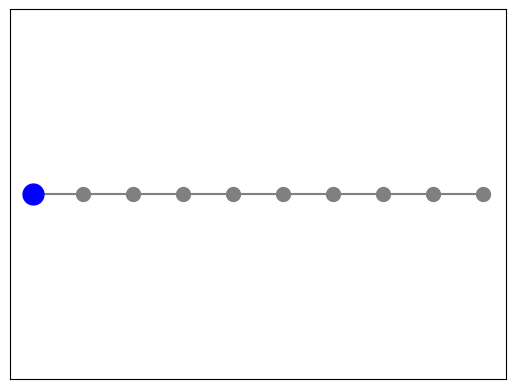

In [1]:
# @title Setup
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# hyperparameters
num_states = 10
num_actions = 2
max_steps = 50

class NumberLineEnv:
    def __init__(self, num_states=4, max_steps=50, move_probability=0.95, reward_type='sparse'):
        self.num_states = num_states
        self.max_steps = max_steps
        self.reward_state = self.num_states-1
        self.move_probability = move_probability
        self.reward_type = reward_type

    def reset(self, key):
        """Initialize the environment state."""
        state = (0, 0, key)
        timestep = (0, 0, False)
        return state, timestep

    def step(self, state, action):
        """Takes an action in the environment."""
        obs, step_count, key = state
        new_key, sub_key = jax.random.split(key)

        # Determine movement direction (intended or opposite)
        in_obsorbing_goal_state = obs == self.reward_state
        intended_direction = jnp.where(in_obsorbing_goal_state, 0, jnp.where(jax.random.uniform(sub_key) < self.move_probability, action, -1))

        # Update position based on stochastic action
        next_obs = jnp.clip(obs + intended_direction, 0, self.reward_state)

        # Calculate instantaneous reward
        is_at_goal = next_obs == self.reward_state
        reward = jax.lax.cond(
            self.reward_type == 'sparse',
            lambda x: jnp.where(x, 1, 0),
            lambda x: jnp.where(~x, -1, 0),
            is_at_goal,
        )
        done = (jnp.where(step_count == self.max_steps-1, 1, 0) + is_at_goal) > 0
        reward = jnp.where(in_obsorbing_goal_state, 0, reward)

        # Update state
        state = (next_obs, step_count + 1, new_key)
        timestep = (next_obs, reward, done)

        return state, timestep

    def _prepare_figure(self, ax):

        # Add labels and legend
        ax.set_xticks([])
        ax.set_yticks([])

    def _draw_state(self, ax, state):
        obs, _, _ = state

        # Create a line for the state space
        states = range(self.num_states)
        ax.plot(states, [0] * len(states), 'o-', color='gray', markersize=10)

        # Mark agent and target state
        ax.plot(self.num_states-1, 0)
        color = 'green' if obs == self.num_states - 1 else 'blue'
        ax.plot(obs, 0, 'o', color=color, markersize=15, label='Agent')


    def render(self, state):
        # Prepare figure and axis
        fig, ax = plt.subplots()
        ax.clear()
        self._prepare_figure(ax)

        # Mark the current state of the agent
        self._draw_state(ax, state)
        plt.show()

    def animate(self, states, interval=200, save_path=None):
        fig = plt.figure()
        fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
        ax = fig.add_subplot(111)
        plt.close(fig)
        self._prepare_figure(ax)

        def make_frame(state) -> None:
            ax.clear()
            self._prepare_figure(ax)
            self._draw_state(ax, state)

        # Create the animation object.
        self._animation = animation.FuncAnimation(
            fig,
            make_frame,
            frames=states,
            interval=interval,
        )

        # Save the animation as a gif.
        if save_path:
            self._animation.save(save_path)

        return self._animation


# policy helper functions
def sample_policy(policy, key):
    keys = jax.random.split(key, num_states)
    return jnp.array([policy(x, key) for x, key in enumerate(keys)])

# create environment
env = NumberLineEnv(num_states=num_states, max_steps=max_steps)
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

# visualise environment
key = jax.random.PRNGKey(3)
env_state, timestep = reset_fn(key)
env.render(env_state)

In [2]:
def get_action_from_q_policy(key, x, Q):
    def random_policy(x):
        return jax.random.choice(key, jnp.array([-1, 1]))

    def greedy_policy(x):
        policy = 2*jnp.argmax(Q, axis=1) - 1
        return policy[x]

    action = jax.lax.cond(
        jnp.sum(Q) == 0,
        random_policy,
        greedy_policy,
        x
    )
    return action

## **Monte Carlo control**

- Greedy policy improvement over $V(s)$ requires model of MDP
  $$ \pi'(s) = \underset{a \in A}{\text{argmax}} \; R_s^a + P_{ss'}^a V(s') $$

- Greedy policy improvement over $Q(s, a)$ is model-free
  $$ \pi'(s) = \underset{a \in A}{\text{argmax}} \; Q(s, a) $$

### **Monte Carlo Q-value prediction** (Policy Evaluation)



In [3]:
num_episodes = 1000
gamma = 0.9
key_init = jax.random.PRNGKey(0)
N_init = jnp.zeros((num_states, num_actions))
Q_init = jnp.zeros((num_states, num_actions))

In [4]:
def scan_rollout_step_fn(state, unused_t):
    Q, env_state = state
    obs, _, key = env_state
    key, action_key = jax.random.split(key)
    action = get_action_from_q_policy(action_key, obs, Q)
    action_idx = ((action + 1)/2).astype(int)
    env_state, timestep = step_fn(env_state, action)
    append = (obs, action_idx, timestep[1], timestep[2])
    return (Q, env_state), (append)

def rollout_episode_fn(key, Q):
    reset_key, policy_key = jax.random.split(key)
    initial_env_state, _ = reset_fn(reset_key)
    initial_state = (Q, initial_env_state)
    (Q, _), (trajectory) = jax.lax.scan(scan_rollout_step_fn, initial_state, jnp.arange(max_steps))

    return jnp.array(trajectory)

batched_rollout_fn = jax.jit(jax.vmap(rollout_episode_fn, in_axes=(0, None)))

In [5]:
def scan_step_fn(state, timestep):
    G, N, Q, next_done = state
    obs, action, reward, done = timestep[0], timestep[1], timestep[2], timestep[3]
    G = gamma * G * (1-done) + reward
    next_done = done - reward
    N = N.at[obs, action].add(1*(1-next_done))
    Q = Q.at[obs, action].set(Q[obs, action] + (G - Q[obs, action]) / (1*(next_done) + N[obs, action]))
    return (G, N, Q, next_done), (G)

def mc_q_prediction(key, Q, N):
    keys = jax.random.split(jax.random.PRNGKey(0), num_episodes)
    trajectories = batched_rollout_fn(keys, Q).transpose(0, 2, 1).reshape((-1, 4))

    initial_state = (0, N, Q, 1)
    (_, N, Q, _), G_hist = jax.lax.scan(scan_step_fn, initial_state, trajectories, reverse=True)
    return Q, G_hist

mc_q_prediction_fn = jax.jit(mc_q_prediction)

In [6]:
Q_pi, G_hist = mc_q_prediction_fn(key_init, Q_init, N_init)
Q_pi

Array([[0.01301974, 0.01675073],
       [0.01266643, 0.02271451],
       [0.01345183, 0.03729634],
       [0.02086471, 0.06273597],
       [0.03526642, 0.1071758 ],
       [0.05937417, 0.19684589],
       [0.11954031, 0.32824814],
       [0.18574654, 0.57960564],
       [0.30320212, 0.96306014],
       [0.        , 0.        ]], dtype=float32)

### **Monte Carlo control using estimated Q-values** (Policy Improvement)

In [7]:
def get_policy_from_q_table(Q):
    def policy(x, key):
        policy = 2*jnp.argmax(Q, axis=1) - 1
        return policy[x]
    return policy

policy = get_policy_from_q_table(Q_pi)
sample_policy(policy, key)

Array([ 1,  1,  1,  1,  1,  1,  1,  1,  1, -1], dtype=int32)

In [9]:
Q_pi, G_hist = mc_q_prediction_fn(key_init, Q_pi, N_init)
Q_pi

Array([[0.01301974, 0.3963597 ],
       [0.01266643, 0.44197348],
       [0.01345183, 0.49612555],
       [0.02086471, 0.5559588 ],
       [0.03526642, 0.62494403],
       [0.05937417, 0.70181423],
       [0.11954031, 0.78715587],
       [0.18574654, 0.8828691 ],
       [0.30320212, 0.99076164],
       [0.        , 0.        ]], dtype=float32)

## **Sarsa - TD control**

Algorithm parameters: step size $\alpha \in (0, 1]$

Initialize: $Q(s, a)$, for all $s \in S$, $a \in A$, arbitrarily except that $Q(\text{terminal}, \cdot) = 0$

for each episode do
- Initialize $S$

- Choose $A$ from $S$ using policy derived from $Q$

- while $S$ is not terminal do
    - Take action $A$, observe $R$, $S'$

    - Choose $A'$ from $S'$ using policy derived from $Q$

    - $Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma Q(S', A') - Q(S, A) \right]$

    - $S \leftarrow S'; A \leftarrow A'$

- end while

end for

In [10]:
# step size
alpha = 0.1

In [11]:
def scan_step_fn(state, unused_t):
    Q, env_state = state
    obs, _, key = env_state
    key, action_key = jax.random.split(key)

    action = get_action_from_q_policy(action_key, obs, Q)
    action_idx = ((action + 1)/2).astype(int)

    env_state, timestep = step_fn(env_state, action)
    next_obs, reward, done = timestep

    # get next action
    next_action = get_action_from_q_policy(action_key, next_obs, Q)
    next_action_idx = ((next_action + 1)/2).astype(int)

    # construct TD target
    TD_target = gamma * Q[next_obs, next_action_idx] * (1-done) + reward
    Q = Q.at[obs, action_idx].set(Q[obs, action_idx] + alpha*(TD_target - Q[obs, action_idx]))
    return (Q, env_state), (TD_target)

def scan_episode_fn(state, unused_t):
    key, Q = state
    key, reset_key = jax.random.split(key)
    initial_env_state, _ = reset_fn(reset_key)

    initial_state = (Q, initial_env_state)
    (Q, _), target_hist = jax.lax.scan(scan_step_fn, initial_state, jnp.arange(max_steps))
    return (key, Q), (target_hist)

def sarsa_prediction(key, Q):
    initial_state = (key, Q)
    (_, Q), target_hist = jax.lax.scan(scan_episode_fn, initial_state, jnp.arange(num_episodes))
    return Q, target_hist

sarsa_prediction_fn = jax.jit(sarsa_prediction)

In [12]:
# initial Q
Q_init

Array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)

In [13]:
# run Sarsa prediction
Q_pi, target_hist = sarsa_prediction_fn(key_init, Q_init)
Q_pi

Array([[0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0.1],
       [0. , 0. ]], dtype=float32)

In [14]:
policy = get_policy_from_q_table(Q_pi)
sample_policy(policy, key)

Array([-1, -1, -1, -1, -1, -1, -1, -1,  1, -1], dtype=int32)

In [15]:
Q_pi, target_hist = sarsa_prediction_fn(key_init, Q_pi)
Q_pi

Array([[0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       [0. , 0.1],
       [0. , 0. ]], dtype=float32)

### **Maintaining exploration using $\epsilon$-greedy policies**

For a discrete action space $A$, let $m = |A|$, then the $\epsilon$-greedy policy is given by

\begin{equation*}
\pi(a | s) =
\begin{cases}
\frac{\epsilon}{m} + 1 - \epsilon & \text{if } a = \arg \max_{a' \in A} Q(s, a'), \\
\frac{\epsilon}{m} & \text{otherwise.}
\end{cases}
\end{equation*}

In [16]:
def epsilon_greedy_action(key, action, epsilon):
    key, subkey = jax.random.split(key)
    random_action = jax.random.choice(key, jnp.array([-1, 1]))
    return jnp.where(jax.random.uniform(subkey) < epsilon, random_action, action)

def exponential_decay(t, half_life=1000):
    return jnp.exp(-jnp.log(2) / half_life * t)

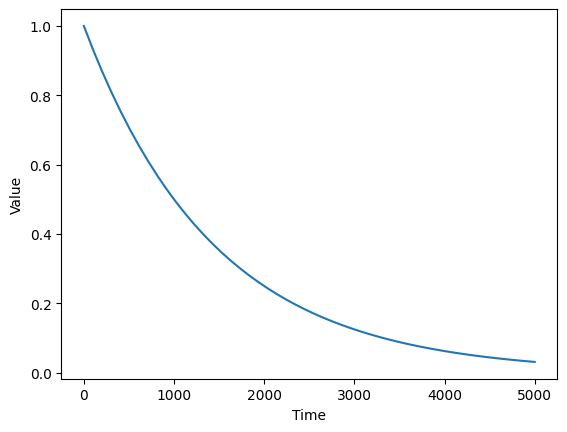

In [17]:
# Time points to calculate the decay function
time_points = jnp.linspace(0, 5000)

# Calculate the decay values
decay_values = exponential_decay(time_points)

# Plot the decay function
plt.plot(time_points, decay_values)
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [18]:
def scan_step_fn(state, unused_t):
    Q, epsilon, env_state = state
    obs, _, key = env_state
    key, a_key, next_a_key, eg_key, next_eg_key = jax.random.split(key, 5)

    action = get_action_from_q_policy(a_key, obs, Q)
    action = epsilon_greedy_action(eg_key, action, epsilon)
    action_idx = ((action + 1)/2).astype(int)

    env_state, timestep = step_fn(env_state, action)
    next_obs, reward, done = timestep

    # get next action
    next_action = get_action_from_q_policy(next_a_key, obs, Q)
    next_action = epsilon_greedy_action(next_eg_key, next_action, epsilon)
    next_action_idx = ((next_action + 1)/2).astype(int)

    # construct TD target
    TD_target = gamma * Q[next_obs, next_action_idx] * (1-done) + reward
    Q = Q.at[obs, action_idx].set(Q[obs, action_idx] + alpha*(TD_target - Q[obs, action_idx]))
    return (Q, epsilon, env_state), (TD_target)

def scan_episode_fn(state, unused_t):
    key, Q, count = state
    key, reset_key = jax.random.split(key)
    initial_env_state, _ = reset_fn(reset_key)
    epsilon = exponential_decay(count)

    initial_state = (Q, epsilon, initial_env_state)
    (Q, _, _), target_hist = jax.lax.scan(scan_step_fn, initial_state, jnp.arange(max_steps))
    return (key, Q, count+1), (target_hist)

def sarsa_with_epsilon_greedy(key, Q):
    initial_state = (key, Q, 1)
    (_, Q, _), target_hist = jax.lax.scan(scan_episode_fn, initial_state, jnp.arange(num_episodes))
    return Q, target_hist

sarsa_with_epsilon_greedy_fn = jax.jit(sarsa_with_epsilon_greedy)

In [19]:
Q_pi, target_hist = sarsa_with_epsilon_greedy_fn(key_init, Q_init)
Q_pi

Array([[0.15151253, 0.18475199],
       [0.15108597, 0.21114913],
       [0.18535806, 0.2639172 ],
       [0.21736482, 0.34520033],
       [0.2743502 , 0.4011726 ],
       [0.34131202, 0.4811325 ],
       [0.41684526, 0.6577814 ],
       [0.4973943 , 0.75892895],
       [0.6748856 , 0.97492725],
       [0.        , 0.        ]], dtype=float32)

In [20]:
policy = get_policy_from_q_table(Q_pi)
sample_policy(policy, key)

Array([ 1,  1,  1,  1,  1,  1,  1,  1,  1, -1], dtype=int32)

## **Off-policy control: decoupling exploration from learning**

- Actions are chosen using a **behaviour** policy $A_{t+1} \sim \mu(\cdot|S_t)$
- Learning is towards a **target** policy with $A' \sim \pi(\cdot|S_t)$
- We update $Q(S_t, A_t)$ towards value of target action

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left( R_{t+1} + \gamma Q(S_{t+1}, A') - Q(S_t, A_t) \right)
$$


### **Q-learning**

Target action $A' \sim \pi'(\cdot|S_t) = \underset{a \in A}{\text{argmax}} \; Q(S_t, a)$

**Algorithm**

Initialize $Q(s, a), \forall s \in S, a \in A(s)$, arbitrarily, and $Q(\text{terminal-state}, \cdot) = 0$

Repeat (for each episode):
- Initialize $S$
- Repeat (for each step of episode):
  - Choose $A$ from $S$ using policy derived from $Q$ (e.g., $\epsilon$-greedy)
  - Take action $A$, observe $R, S'$
  - $Q(S, A) \leftarrow Q(S, A) + \alpha \left[R + \gamma \max_{a} Q(S', a) - Q(S, A)\right]$
  - $S \leftarrow S';$
- until $S$ is terminal


In [21]:
def scan_step_fn(state, unused_t):
    Q, epsilon, env_state = state
    obs, _, key = env_state
    key, a_key, eg_key = jax.random.split(key, 3)

    action = get_action_from_q_policy(a_key, obs, Q)
    action = epsilon_greedy_action(eg_key, action, epsilon)
    action_idx = ((action + 1)/2).astype(int)

    env_state, timestep = step_fn(env_state, action)
    next_obs, reward, done = timestep

    # construct TD target
    TD_target = gamma * jnp.max(Q[next_obs]) + reward
    Q = Q.at[obs, action_idx].set(Q[obs, action_idx] + alpha*(TD_target - Q[obs, action_idx]))
    return (Q, epsilon, env_state), (TD_target)

def scan_episode_fn(state, unused_t):
    key, Q, count = state
    key, reset_key = jax.random.split(key)
    initial_env_state, _ = reset_fn(reset_key)
    epsilon = 0.9 # HARDCODED

    initial_state = (Q, epsilon, initial_env_state)
    (Q, _, _), target_hist = jax.lax.scan(scan_step_fn, initial_state, jnp.arange(max_steps))
    return (key, Q, count+1), (target_hist)

def q_learning(key, Q):
    initial_state = (key, Q, 1)
    (_, Q, _), target_hist = jax.lax.scan(scan_episode_fn, initial_state, jnp.arange(num_episodes))
    return Q, target_hist

q_learning_fn = jax.jit(q_learning)

In [22]:
Q_pi, target_hist = q_learning_fn(key_init, Q_init)
Q_pi

Array([[0.35109365, 0.39152205],
       [0.3520215 , 0.43532446],
       [0.39198261, 0.48514956],
       [0.4440828 , 0.5565262 ],
       [0.49767965, 0.6235937 ],
       [0.5570654 , 0.69750047],
       [0.62559503, 0.7776196 ],
       [0.6992302 , 0.8723612 ],
       [0.77902216, 0.9840508 ],
       [0.        , 0.        ]], dtype=float32)

In [ ]:
policy = get_policy_from_q_table(Q_pi)
sample_policy(policy, key)